In [11]:
# Copying the Best Results from Each Config for Comparison

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec


In [13]:
CLASS_NAMES = ["No Damage", "Minor", "Major", "Destroyed", "Unclassified"]

In [17]:
{
        "name": "UNet",
        "loss": 0.1805,
        "miou": 0.2785,
        "acc":  0.9644,
        "iou":    [0.9754, 0.3742, 0.0172, 0.0116, 0.0141],
    },
MODELS = [
    {
        "name": "UNet+Tversky",
        "loss": 0.9100,
        "miou": 0.3194,
        "acc":  0.9183,
        "iou":    [0.9415, 0.5796, 0.0423, 0.0143, 0.0191],
        "prec":   [0.9683, 0.6771, 0.1023, 0.2078, 0.0364],
        "recall": [0.9714, 0.8009, 0.0673, 0.0152, 0.0386],
    },
    {
        "name": "Siamese UNet",
        "loss": 1.5516,
        "miou": 0.2271,
        "acc":  0.8634,
        "iou":    [0.8851, 0.2185, 0.0185, 0.0039, 0.0096],
        "prec":   [0.8998, 0.4626, 0.1122, 0.1595, 0.0040],
        "recall": [0.9819, 0.2928, 0.0217, 0.0040, 0.0120],
    },
    {
        "name": "Siamese (Custom Weights)",
        "loss": 1.1464,
        "miou": 0.3075,
        "acc":  0.8983,
        "iou":    [0.9164, 0.5304, 0.0313, 0.0505, 0.0090],
        "prec":   [0.9687, 0.6021, 0.0967, 0.2660, 0.0126],
        "recall": [0.9444, 0.8167, 0.0442, 0.057, 0.0303],
    },
    {
        "name": "Siamese (OHEM)",
        "loss": 0.7230,
        "miou": 0.3170,
        "acc":  0.9228,
        "iou":    [0.9439, 0.5866, 0.0174, 0.0149, 0.0219],
        "prec":   [0.9628, 0.6986, 0.0978, 0.2342, 0.0682],
        "recall": [0.9796, 0.7854, 0.0208, 0.0157, 0.0313],
    }


    # ── Paste new models below ──────────────────────────────────────────────
    # {
    #     "name": "My New Model",
    #     "loss": 0.0,
    #     "miou": 0.0,
    #     "acc":  0.0,
    #     "iou":    [0.0, 0.0, 0.0, 0.0, 0.0],
    #     "prec":   [0.0, 0.0, 0.0, 0.0, 0.0],
    #     "recall": [0.0, 0.0, 0.0, 0.0, 0.0],
    # },
]

COLORS = [
    "#00e5ff", "#ff6b6b", "#69ff47", "#ffd93d",
    "#c77dff", "#ff9a3c", "#4ecdc4", "#ff6eb4",
]





In [18]:
def plot_comparison(models, save_path="model_comparison.png"):
    n_models = len(models)
    n_classes = len(CLASS_NAMES)

    plt.style.use("seaborn-v0_8-whitegrid")
    colors = [COLORS[i % len(COLORS)] for i in range(n_models)]

    fig = plt.figure(figsize=(16, 11))
    fig.suptitle("XBD Damage Segmentation — Model Comparison", fontsize=13, fontweight="bold", y=0.98)

    gs = GridSpec(3, 4, figure=fig, hspace=0.6, wspace=0.4,
                  top=0.93, bottom=0.07, left=0.07, right=0.97)

    # ── 1. Summary metrics (top row, spans all cols) ─────────────────────────
    ax_sum = fig.add_subplot(gs[0, :])

    summary_metrics = ["miou", "acc", "loss"]
    summary_labels  = ["mIoU", "Accuracy", "Loss"]
    n_summary = len(summary_metrics)
    group_w = 0.6
    bar_w = group_w / n_models
    offsets = np.linspace(-(group_w / 2) + bar_w / 2, (group_w / 2) - bar_w / 2, n_models)

    for g, (metric, label) in enumerate(zip(summary_metrics, summary_labels)):
        for m_idx, (model, color) in enumerate(zip(models, colors)):
            val = model[metric]
            x = g + offsets[m_idx]
            ax_sum.bar(x, val, width=bar_w * 0.85, color=color,
                       label=model["name"] if g == 0 else "_nolegend_")
            ax_sum.text(x, val + 0.01, f"{val:.4f}", ha="center", va="bottom",
                        fontsize=8, color=color, fontweight="bold")

    ax_sum.set_xticks(range(n_summary))
    ax_sum.set_xticklabels(summary_labels, fontsize=11)
    ax_sum.set_ylim(0, 1.18)
    ax_sum.set_ylabel("Score")
    ax_sum.set_title("Summary Metrics", fontsize=11, loc="left")
    ax_sum.legend(loc="upper right", fontsize=9, framealpha=0.8)
    ax_sum.tick_params(axis="x", bottom=False)

    # ── 2. Per-class metrics ──────────────────────────────────────────────────
    # IoU spans all 4 cols; Precision and Recall each span 2 cols → equal width
    per_class_metrics = [
        ("iou",    "Per-Class IoU",       gs[1, :]),
        ("prec",   "Per-Class Precision", gs[2, 0:2]),
        ("recall", "Per-Class Recall",    gs[2, 2:4]),
    ]

    x = np.arange(n_classes)
    bar_w_pc = 0.7 / n_models
    offsets_pc = np.linspace(-(0.7 / 2) + bar_w_pc / 2, (0.7 / 2) - bar_w_pc / 2, n_models)

    for metric, title, subplot_spec in per_class_metrics:
        ax = fig.add_subplot(subplot_spec)

        for m_idx, (model, color) in enumerate(zip(models, colors)):
            vals = model[metric]
            ax.bar(x + offsets_pc[m_idx], vals, width=bar_w_pc * 0.85, color=color)

            if metric == "iou":
                for xi, v in zip(x + offsets_pc[m_idx], vals):
                    ax.text(xi, v + 0.008, f"{v:.3f}", ha="center", va="bottom",
                            fontsize=7, color=color, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_NAMES, fontsize=9, rotation=15, ha="right")
        ax.set_ylim(0, 1.12)
        ax.set_ylabel("Score", fontsize=9)
        ax.set_title(title, fontsize=11, loc="left")
        ax.tick_params(axis="x", bottom=False)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved → {save_path}")
    plt.show()

Saved → model_comparison.png


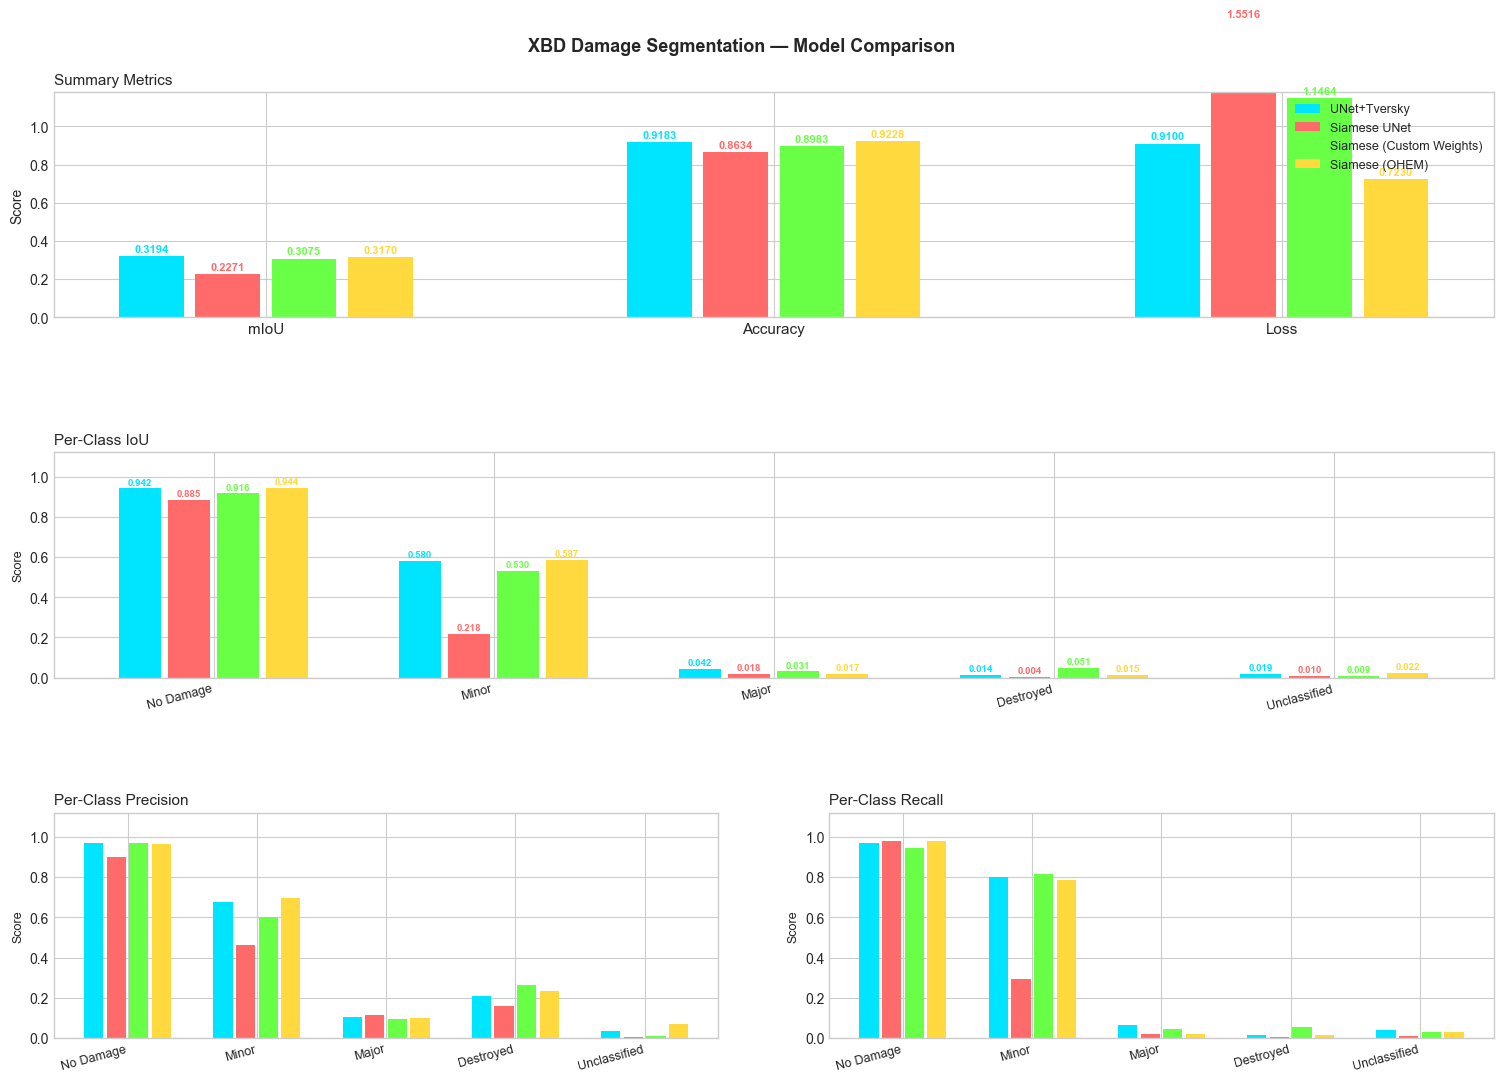

In [19]:
plot_comparison(MODELS)